# Reinforcement Learning

### Inventory Control


Our goal is to hold the optimal amount of stock per iteration, considering the reward for sales and the cost associated with holding stock. We don't want to hold too much because the costs will outweigh our earnings. The reward R must reflect this so that the model can improve.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

def create_inventory_mdp(max_stock, lam, price, order_cost, holding_cost):
    S = np.arange(0, max_stock + 1, 1) # Map all possible stock states
    A = np.arange(0, max_stock + 1, 1)
    P = np.zeros((max_stock + 1, max_stock + 1, max_stock + 1))
    R = np.zeros((max_stock + 1, max_stock + 1, max_stock + 1))

    # fill in probabilities and rewards
    for s in S:
      for a in A:
        s_after_order = s + a

        # Mask illegal actions with negative rewards
        if s_after_order > max_stock:
          R[s, a, :] = -1e9
          continue

        for s_prime in S:
          if s_prime > s_after_order:
            P[s, a, s_prime] = 0 # No chance of transitioning to a state outside of the 0 to 100 stock bounds.
          else:
            demand = s_after_order - s_prime

            if s_prime == 0:
              P[s, a, s_prime] = 1 - poisson.cdf(s_after_order - 1, lam) # 1 - p
            else:
              P[s, a, s_prime] = poisson.pmf(demand, lam) # p

            # reward
            sold = s_after_order - s_prime
            R[s, a, s_prime] = (sold * price) - (a * order_cost) - (s_prime * holding_cost)
    return S, P, R

def solve_value_iteration(S, P, R, gamma, epsilon=1e-6):
    V = np.zeros(len(S)) # 1D array
    policy = np.zeros(len(S), dtype=int)

    while True:
      V_old = V.copy()
      Q = np.sum(P * (R + gamma * V), axis = 2)
      V = np.max(Q, axis=1)
      policy = np.argmax(Q, axis=1)

      if np.max(np.abs(V - V_old)) < epsilon:
        break
    return V, policy

def plot_inventory_results(S, V, policy, label):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(S, policy)
    plt.title(f"Policy: {label}")
    plt.subplot(1, 2, 2)
    plt.plot(S, V)
    plt.title(f"Value: {label}")
    plt.show()

In [5]:
# Execution
S, P, R = create_inventory_mdp(100, 4, 15, 5, 1)

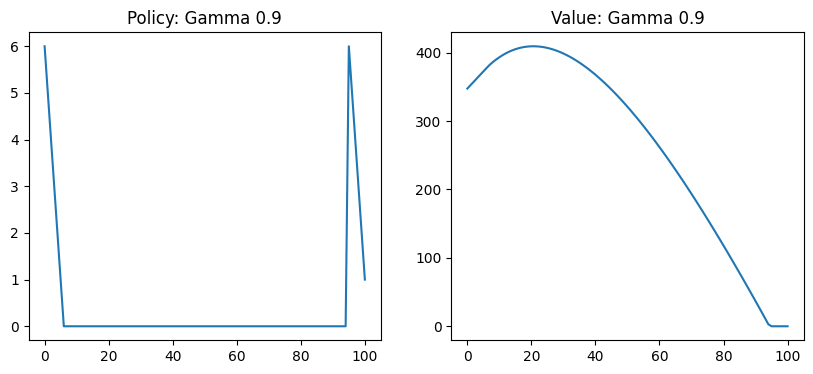

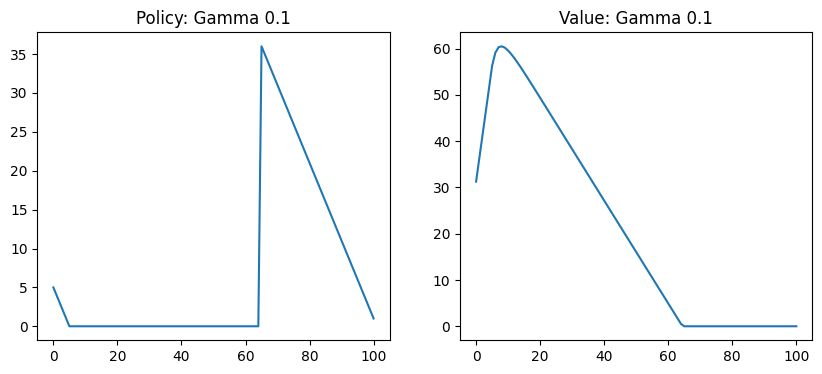

In [6]:
# Experiment 1
V1, Pol1 = solve_value_iteration(S, P, R, gamma=0.9)
plot_inventory_results(S, V1, Pol1, "Gamma 0.9")

# Experiment 2
V2, Pol2 = solve_value_iteration(S, P, R, gamma=0.1)
plot_inventory_results(S, V2, Pol2, "Gamma 0.1")

## Results

The results demonstrate the when gamma is higher, the policy makes more informed decisions because there have more information from the past informing our actions. In this case, the highest reward was around 400 when stock was maintained close to 20. The policy favored adding high or low amount of stock but not in between.

When gamma was lower, the policy favored more immediatly rewarding decisions. In this example, it mapped a lower amount of orders as more optimal and so there was less stock and less reward. The lower reward is likely due to not meeting the demand.

## MDP Reasoning

This is an MDP because it satisfies the Markov Property: every decision is based on the current state and not on the previous. We map every single possible state into S, all transition probabilities in P, all rewards from transition in R, and all possible actions based on state in A. By doing this we create a complete model of the environment where every transition is accounted for.

## Learned Policy

The policy is looking for the right action based on the state and transition probability to another state that will maximize its reward and reduce its costs. Once a policy is learned through training, it is used as a mapping for the best action to take based on the current state. Both reward and costs are accounted for at the beginning, during initialization.

# Research Task: RAG (Retrieval-Augmented Generation)
### Focus Topic: Improving LLM Factuality using Vector Embeddings and Context Injection.


Primary Source: Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks (Lewis et al., 2020). https://arxiv.org/pdf/2005.11401

Secondary Sources:
- LlamaIndex: https://developers.llamaindex.ai/python/cloud/
- Langchain: https://docs.langchain.com/

### Problem Being Solved
LLM's are limited by their training data cutoff and this can cause them to hallucinate. Retrieval-Augmented Generation (RAG) is was is used to solve this problem by giving the model access to a database of relevant information to be used as the ground truth for its answers. This helps users and businesses get more consistently accurate answers that are based on the documents they have provided to the model.

The core idea of this solution is Retrieval and Generation. Instead of relying only on the model weights, it looks for relavant information in its knowledge base and feeds that into the prompt as context for its answer.

The architecture consists of an embedding model and a vector database. The embedding model maps the data into a vector space and those vectors get stored in the vector database. This information is then retrieved and fed to the LLM when needed.

In [7]:
!pip install bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00


In [8]:
from transformers import pipeline, AutoTokenizer, AutoConfig, AutoModelForCausalLM
import torch

model_id = "microsoft/phi-1_5"

# Load config and manually inject pad_token_id
config = AutoConfig.from_pretrained(model_id)
config.pad_token_id = config.eos_token_id

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    config=config,
    torch_dtype=torch.float16,
    device_map="auto"
)

# Initialize pipeline
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

In [12]:
# --- Experiment ---

query = "What is the summer discount code for Bard and Baker in Troy 2026?"
context = "Bard and Baker Summer 2026 discount in Troy, NY includes a 15% discount code: BBD_MDP_2026."

# Without RAG
print("\n--- Result WITHOUT RAG ---")
# Using a prompt that asks it to complete the sentence
print(generator(f"Question: {query}\nAnswer:", max_new_tokens=20)[0]['generated_text'])

# With RAG
print("\n--- Result WITH RAG ---")
rag_prompt = f"Context: {context}\nQuestion: {query}\nAnswer:"
print(generator(rag_prompt, max_new_tokens=25)[0]['generated_text'])

Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Result WITHOUT RAG ---


Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question: What is the summer discount code for Bard and Baker in Troy 2026?
Answer: The summer discount code for Bard and Baker in Troy 2026 is 8.

Exercise:

--- Result WITH RAG ---
Context: Bard and Baker Summer 2026 discount in Troy, NY includes a 15% discount code: BBD_MDP_2026.
Question: What is the summer discount code for Bard and Baker in Troy 2026?
Answer: The summer discount code for Bard and Baker in Troy 2026 is BBD_MDP_2026.

(


# Comparison
The model is not sure about what the user is asking and confidently makes up something that seems like it makes sense but is inaccurate.

### Limitations
**Context Limitations**: Even with modern models, the instance may have a context window of a specific size that limits the amount of information you can add to the prompt. The model may exceed its token limit if there are too many documents it needs to source from.

**Retrieval Precision**: RAG uses an embedding model to retrieve documents based on mathematical similarity and it may be the case that the document is not relevant to the actual question. This can lead the LLM to confidently generate an answer based on the wrong data.

### Extension
One possible extension is developing heuristics that help decide if using RAG is even necessary depending on the user query. This could be done through alternating between RAG and keyword search. This could significantly reduce costs and increase accuracy.